# Hughes Continuum Model — Square Room, Top-Middle Exit

Implementation of the Hughes (2002) macroscopic pedestrian dynamics model.  
**Scenario:** 10 m × 10 m square room, single 1 m exit centred on the top wall.  
Uses the Fast Sweeping Method to solve the Eikonal equation at each time step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

In [32]:
# ── Domain ────────────────────────────────────────────────────────────────────
ROOM_W   = 10.0    # room width  (m)
ROOM_H   = 10.0    # room height (m)
EXIT_W   = 1.0     # exit width  (m)   — centred on top wall

# ── Grid ──────────────────────────────────────────────────────────────────────
NX, NY   = 100, 100
dx       = ROOM_W / NX   # 0.10 m per cell
dy       = ROOM_H / NY   # 0.10 m per cell

# ── Pedestrian parameters ─────────────────────────────────────────────────────
rho_init = 4.0    # initial uniform density  (people / m²)
rho_max  = 8.0    # jam density              (people / m²)
u_max    = 1.4    # free-flow speed          (m / s)
alpha    = 0.1    # discomfort parameter

# ── Time ──────────────────────────────────────────────────────────────────────
# CFL condition: dt <= dx / u_max  →  0.1/1.4 ≈ 0.071 s  → use 0.05 s
dt       = 0.05   # time step  (s)
T_TOTAL  = 300.0   # total simulation time (s)
n_steps  = int(T_TOTAL / dt)

# ── Eikonal solver ────────────────────────────────────────────────────────────
MAX_SWEEP_ITERS = 6   # fast sweeping converges quickly; 6 is generous

# ── Output ────────────────────────────────────────────────────────────────────
PLOT_TIMES  = [0, 5, 10, 20, 40, 60]   # seconds at which to save snapshots
ANIM_SKIP   = 20                        # store every N-th step for animation

print(f"Grid:        {NX} × {NY} cells, dx=dy={dx:.3f} m")
print(f"Room:        {ROOM_W} m × {ROOM_H} m")
print(f"Exit:        {EXIT_W} m wide, centred on top wall")
print(f"CFL limit:   dt ≤ {dx/u_max:.4f} s  →  using dt = {dt} s")
print(f"Steps:       {n_steps}  ({T_TOTAL} s total)")
total_people = rho_init * ROOM_W * ROOM_H
print(f"Initial pop: {total_people:.0f} people")

Grid:        100 × 100 cells, dx=dy=0.100 m
Room:        10.0 m × 10.0 m
Exit:        1.0 m wide, centred on top wall
CFL limit:   dt ≤ 0.0714 s  →  using dt = 0.05 s
Steps:       6000  (300.0 s total)
Initial pop: 400 people


Exit columns: 45 – 54  (10 cells = 1.00 m)
Exit physical x-range: 4.50 – 5.50 m


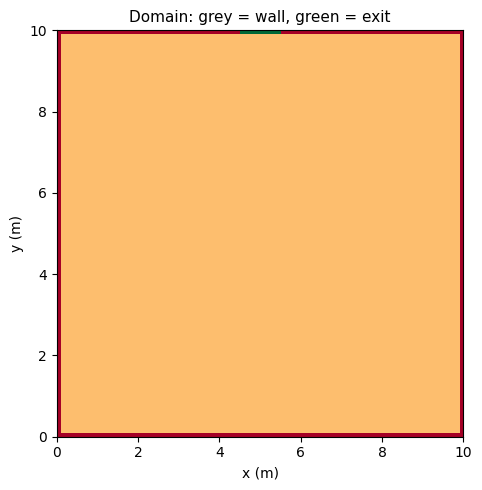

Domain built successfully.


In [15]:
# ── Build domain masks ────────────────────────────────────────────────────────

# boundary[i, j] = True  →  wall cell (rho = 0, no-flux)
boundary = np.zeros((NY, NX), dtype=bool)
boundary[0,  :]  = True   # bottom wall
boundary[-1, :]  = True   # top wall
boundary[:,  0]  = True   # left wall
boundary[:, -1]  = True   # right wall

# exit: centred on top wall
exit_cells  = max(1, round(EXIT_W / dx))   # number of columns in exit
cx          = NX // 2                       # centre column
col0        = cx - exit_cells // 2
col1        = col0 + exit_cells
exit_cols   = slice(col0, col1)

boundary[-1, exit_cols] = False   # open the top wall at the exit
exit_zone   = np.zeros((NY, NX), dtype=bool)
exit_zone[-1, exit_cols] = True   # mark exit cells

print(f"Exit columns: {col0} – {col1-1}  ({exit_cells} cells = {exit_cells*dx:.2f} m)")
print(f"Exit physical x-range: {col0*dx:.2f} – {col1*dx:.2f} m")

# Quick domain visualisation
fig, ax = plt.subplots(figsize=(5, 5))
vis = np.zeros((NY, NX))
vis[boundary]  = -1   # walls → dark
vis[exit_zone] =  2   # exit  → bright
ax.imshow(vis, origin='lower', cmap='RdYlGn',
          extent=[0, ROOM_W, 0, ROOM_H], vmin=-1, vmax=2)
ax.set_title('Domain: grey = wall, green = exit', fontsize=11)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout(); plt.show()
print("Domain built successfully.")

In [16]:
def speed_fn(rho):
    """Linear speed-density: U(rho) = u_max * max(eps, 1 - rho/rho_max)
    
    Regularised with a small floor eps to keep the Eikonal cost finite
    even at jam density, avoiding the turning-point blow-up.
    """
    return u_max * np.maximum(1e-3, 1.0 - rho / rho_max)

def discomfort_fn(rho):
    """Discomfort (cost weight): G(rho) = 1 / (1 + alpha*rho)
    
    Pedestrians prefer less congested routes; combined with speed this
    gives the Eikonal cost  f = G / U.
    """
    return 1.0 / (1.0 + alpha * rho)

# Sanity check
rhos = np.array([0, 2, 4, 6, 8])
print("rho   U(rho)   G(rho)   cost=G/U")
for r in rhos:
    U = speed_fn(r); G = discomfort_fn(r)
    print(f"  {r}    {U:.3f}    {G:.3f}    {G/U:.3f}")

rho   U(rho)   G(rho)   cost=G/U
  0    1.400    1.000    0.714
  2    1.050    0.833    0.794
  4    0.700    0.714    1.020
  6    0.350    0.625    1.786
  8    0.001    0.556    396.825


Eikonal solver defined.


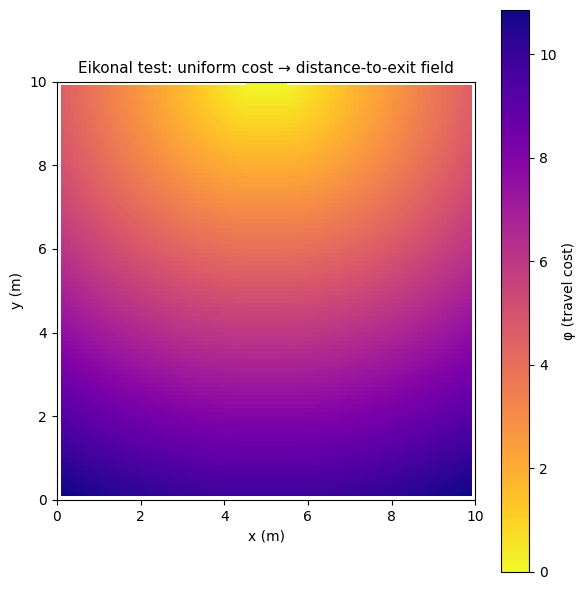

phi min=0.10, max=10.86


In [30]:
def solve_eikonal_fast_sweeping(cost, exit_zone, boundary, dx, dy,
                                max_iter=MAX_SWEEP_ITERS):
    """Solve |∇φ| = cost  with φ=0 on exit, using the Fast Sweeping Method.
    
    Four alternating sweep directions ensure information propagates
    from the exit to every interior point regardless of geometry.
    """
    NY, NX = cost.shape
    phi = np.full((NY, NX), 1.0e6)
    phi[exit_zone] = 0.0

    sweeps = [
        (range(1, NY-1), range(1, NX-1)),   # forward-forward
        (range(NY-2, 0, -1), range(1, NX-1)),   # backward-forward
        (range(1, NY-1), range(NX-2, 0, -1)),   # forward-backward
        (range(NY-2, 0, -1), range(NX-2, 0, -1)), # backward-backward
    ]

    for iteration in range(max_iter):
        phi_old = phi.copy()
        for row_range, col_range in sweeps:
            for i in row_range:
                for j in col_range:
                    if boundary[i, j] or exit_zone[i, j]:
                        continue
                    phi[i, j] = min(_update_point(phi, i, j,
                                                   cost[i, j], dx, dy,
                                                   boundary), phi[i, j])
        if np.max(np.abs(phi - phi_old)) < 1e-6:
            break

    phi[exit_zone] = 0.0
    return phi


def _update_point(phi, i, j, c_ij, dx, dy, boundary):
    """Upwind quadratic update at a single interior point."""
    # Gather the smaller neighbour in each axis direction
    nbr_x, nbr_y = [], []
    for di, dj in [(-1, 0), (1, 0)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < phi.shape[0] and not boundary[ni, j]:
            nbr_x.append(phi[ni, j])
    for di, dj in [(0, -1), (0, 1)]:
        ni, nj = i + di, j + dj
        if 0 <= nj < phi.shape[1] and not boundary[i, nj]:
            nbr_y.append(phi[i, nj])

    phi_x = min(nbr_x) if nbr_x else 1.0e6
    phi_y = min(nbr_y) if nbr_y else 1.0e6

    # 1-D or 2-D upwind update
    if abs(phi_x - phi_y) >= c_ij * min(dx, dy):
        return min(phi_x + c_ij * dx, phi_y + c_ij * dy)
    else:
        a  = 1.0/dx**2 + 1.0/dy**2
        b  = -2.0 * (phi_x/dx**2 + phi_y/dy**2)
        cc = phi_x**2/dx**2 + phi_y**2/dy**2 - c_ij**2
        disc = b**2 - 4.0*a*cc
        if disc >= 0:
            return (-b + np.sqrt(disc)) / (2.0*a)
        else:
            return min(phi_x + c_ij*dx, phi_y + c_ij*dy)


print("Eikonal solver defined.")

# ── Test: uniform cost (phi should look like city-block distance to exit) ──
cost_test = np.ones((NY, NX))
cost_test[boundary] = 1.0e6
phi_test  = solve_eikonal_fast_sweeping(cost_test, exit_zone, boundary, dx, dy)

fig, ax = plt.subplots(figsize=(6, 6))
phi_vis = np.ma.masked_where(boundary, phi_test)
im = ax.imshow(phi_vis, origin='lower', cmap='plasma_r',
               extent=[0, ROOM_W, 0, ROOM_H])
plt.colorbar(im, ax=ax, label='φ (travel cost)')
ax.set_title('Eikonal test: uniform cost → distance-to-exit field', fontsize=11)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout(); plt.show()
print(f"phi min={phi_test[~boundary&~exit_zone].min():.2f}, "
      f"max={phi_test[~boundary&~exit_zone].max():.2f}")

In [18]:
def compute_velocity(phi, rho, dx, dy, boundary, exit_zone):
    """Compute velocity field  v = -U(rho) * ∇φ / |∇φ|.
    
    Uses central differences in the interior, one-sided at domain edges.
    Velocity is zeroed on walls; at the exit cells it points upward (out).
    """
    NY, NX = phi.shape
    gx = np.zeros_like(phi)
    gy = np.zeros_like(phi)

    for i in range(NY):
        for j in range(NX):
            if boundary[i, j]:
                continue

            # x-gradient (columns)
            left  = not boundary[i, j-1] if j > 0    else False
            right = not boundary[i, j+1] if j < NX-1 else False
            if left and right:
                gx[i, j] = (phi[i, j+1] - phi[i, j-1]) / (2*dx)
            elif right:
                gx[i, j] = (phi[i, j+1] - phi[i, j ]) / dx
            elif left:
                gx[i, j] = (phi[i, j  ] - phi[i, j-1]) / dx

            # y-gradient (rows)
            down = not boundary[i-1, j] if i > 0    else False
            up   = not boundary[i+1, j] if i < NY-1 else False
            if down and up:
                gy[i, j] = (phi[i+1, j] - phi[i-1, j]) / (2*dy)
            elif up:
                gy[i, j] = (phi[i+1, j] - phi[i,   j]) / dy
            elif down:
                gy[i, j] = (phi[i,   j] - phi[i-1, j]) / dy

    mag = np.sqrt(gx**2 + gy**2)
    mag = np.maximum(mag, 1e-8)

    U  = speed_fn(rho)
    vx = -U * gx / mag
    vy = -U * gy / mag

    vx[boundary] = 0.0
    vy[boundary] = 0.0

    return vx, vy


print("Velocity function defined.")

Velocity function defined.


In [19]:
def update_density(rho, vx, vy, dt, dx, dy, boundary, exit_zone):
    """Advance density one step: ∂ρ/∂t + ∇·(ρv) = 0.
    
    First-order upwind scheme for the advective flux divergence.
    Exit cells are drained to zero each step (absorbing BC).
    Returns (rho_new, people_left_this_step).
    """
    NY, NX = rho.shape
    rho_new = rho.copy()

    for i in range(1, NY-1):
        for j in range(1, NX-1):
            if boundary[i, j]:
                continue

            # Upwind density gradient — x direction
            if vx[i, j] >= 0:
                drho_dx = (rho[i, j] - rho[i, j-1]) / dx
            else:
                drho_dx = (rho[i, j+1] - rho[i, j]) / dx

            # Upwind density gradient — y direction
            if vy[i, j] >= 0:
                drho_dy = (rho[i, j] - rho[i-1, j]) / dy
            else:
                drho_dy = (rho[i+1, j] - rho[i, j]) / dy

            # Velocity divergence (central differences)
            dvx_dx = (vx[i, j+1] - vx[i, j-1]) / (2*dx)
            dvy_dy = (vy[i+1, j] - vy[i-1, j]) / (2*dy)

            rho_new[i, j] = rho[i, j] - dt * (
                rho[i, j] * (dvx_dx + dvy_dy)
                + vx[i, j] * drho_dx
                + vy[i, j] * drho_dy
            )

    # Enforce physical bounds
    rho_new = np.clip(rho_new, 0.0, rho_max)
    rho_new[boundary] = 0.0

    # Absorbing exit: count and remove
    people_leaving = np.sum(rho_new[exit_zone]) * dx * dy
    rho_new[exit_zone] = 0.0

    if np.any(np.isnan(rho_new)):
        rho_new = np.nan_to_num(rho_new, nan=0.0)
        print("WARNING: NaN corrected")

    return rho_new, people_leaving


print("Density update function defined.")

Density update function defined.


In [20]:
import time

# ── Initialise ────────────────────────────────────────────────────────────────
rho = np.where(boundary | exit_zone, 0.0, rho_init)

snapshot_frames  = {}   # {time_in_s: rho_array}
anim_frames      = []   # list of (t, rho) for animation
evac_curve_t     = []   # time series
evac_curve_pop   = []   # people remaining

plot_step_set = {int(round(t / dt)) for t in PLOT_TIMES}
total_people  = np.sum(rho) * dx * dy

print(f"Initial population: {total_people:.1f} people")
print(f"Running {n_steps} steps... (this will take a few minutes)")
t_start = time.time()

for step in range(n_steps):
    t = step * dt

    # Record population
    if step % 5 == 0:
        evac_curve_t.append(t)
        evac_curve_pop.append(np.sum(rho) * dx * dy)

    # Store snapshot at requested plot times
    if step in plot_step_set:
        snapshot_frames[t] = rho.copy()
        pop = np.sum(rho) * dx * dy
        print(f"  Snapshot at t={t:.1f}s  —  {pop:.1f} people remaining")

    # Store animation frame
    if step % ANIM_SKIP == 0:
        anim_frames.append((t, rho.copy()))

    # Eikonal cost
    U    = speed_fn(rho)
    G    = discomfort_fn(rho)
    cost = G / np.maximum(U, 1e-10)
    cost[boundary]  = 1.0e6
    cost[exit_zone] = 0.0

    # Solve Eikonal
    phi = solve_eikonal_fast_sweeping(cost, exit_zone, boundary, dx, dy)

    # Velocity
    vx, vy = compute_velocity(phi, rho, dx, dy, boundary, exit_zone)

    # Update density
    rho, leaving = update_density(rho, vx, vy, dt, dx, dy, boundary, exit_zone)

    total_people = np.sum(rho) * dx * dy

    if step % 200 == 0:
        elapsed = time.time() - t_start
        print(f"  step {step:4d}/{n_steps}  t={t:.1f}s  "
              f"people={total_people:.1f}  elapsed={elapsed:.0f}s")

    if total_people < 1.0:
        print(f"  Room evacuated at t={t:.1f}s")
        # Store final snapshot
        for pt in PLOT_TIMES:
            if int(round(pt/dt)) > step and pt not in snapshot_frames:
                snapshot_frames[pt] = rho.copy()
        break

# Ensure we have the final state for every requested plot time
for pt in PLOT_TIMES:
    if pt not in snapshot_frames:
        snapshot_frames[pt] = rho.copy()

evac_curve_t.append(t)
evac_curve_pop.append(np.sum(rho) * dx * dy)

print(f"\nSimulation complete in {time.time()-t_start:.0f}s")
print(f"Animation frames: {len(anim_frames)}")

Initial population: 384.2 people
Running 6000 steps... (this will take a few minutes)
  Snapshot at t=0.0s  —  384.2 people remaining
  step    0/6000  t=0.0s  people=382.2  elapsed=0s
  Snapshot at t=5.0s  —  377.6 people remaining
  Snapshot at t=10.0s  —  360.6 people remaining
  step  200/6000  t=10.0s  people=360.4  elapsed=177s
  Snapshot at t=20.0s  —  334.8 people remaining
  step  400/6000  t=20.0s  people=334.7  elapsed=579s
  step  600/6000  t=30.0s  people=315.4  elapsed=773s
  Snapshot at t=40.0s  —  300.3 people remaining
  step  800/6000  t=40.0s  people=300.2  elapsed=971s
  step 1000/6000  t=50.0s  people=287.7  elapsed=1171s
  Snapshot at t=60.0s  —  276.6 people remaining
  step 1200/6000  t=60.0s  people=276.5  elapsed=1376s
  step 1400/6000  t=70.0s  people=271.1  elapsed=1581s
  step 1600/6000  t=80.0s  people=266.7  elapsed=1784s
  step 1800/6000  t=90.0s  people=265.0  elapsed=1985s
  step 2000/6000  t=100.0s  people=264.1  elapsed=2196s
  step 2200/6000  t=110.

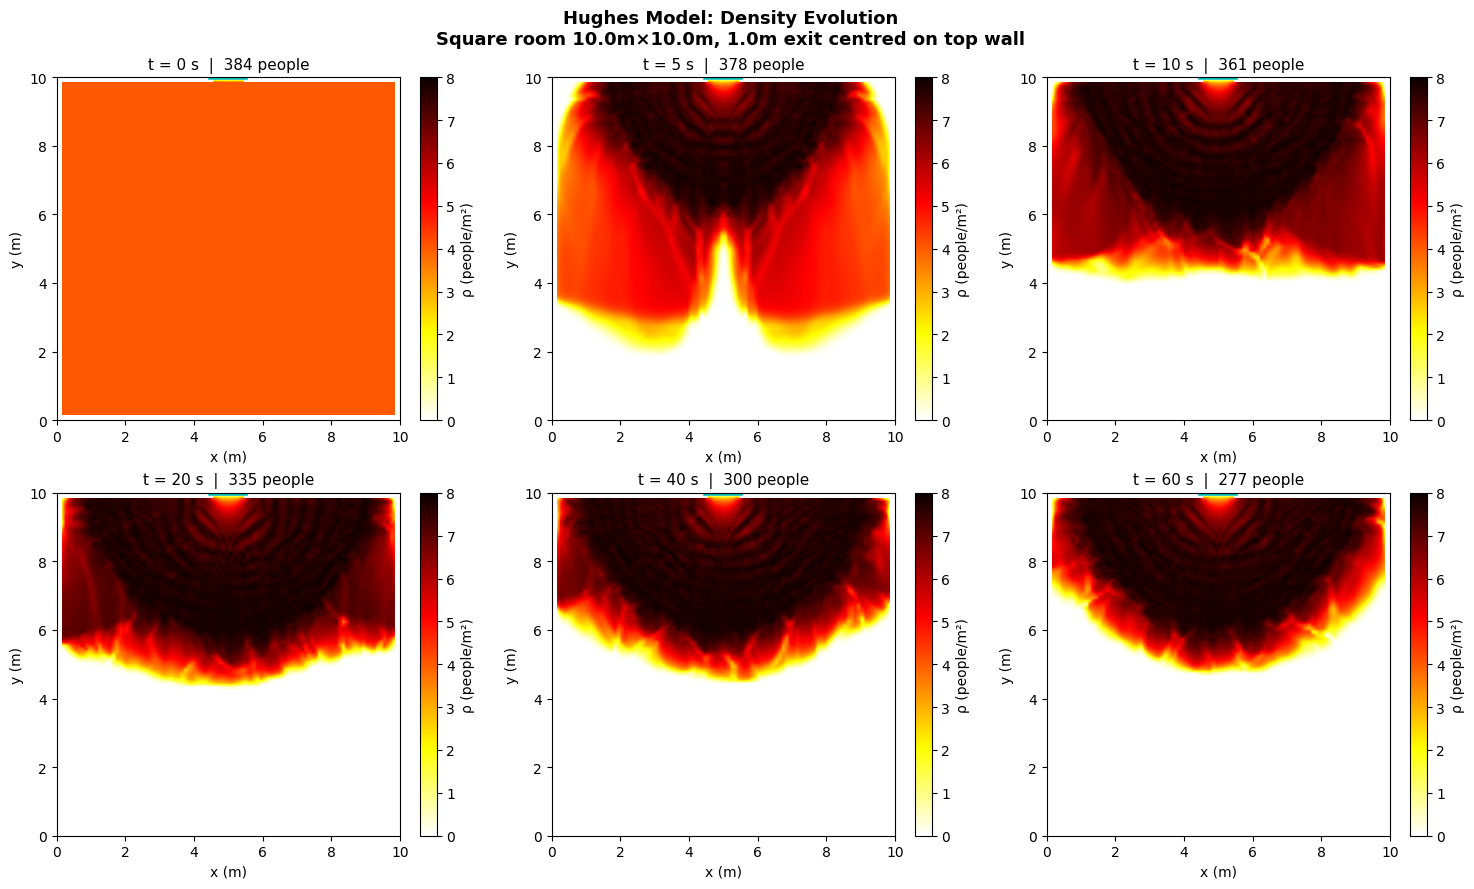

Snapshot figure saved as 'hughes_snapshots.png'


In [ ]:
# ── Density snapshots at requested times ──────────────────────────────────────
cmap_dens = plt.cm.hot_r

times_to_plot = sorted(snapshot_frames.keys())
n_plots = len(times_to_plot)
ncols   = 3
nrows   = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.array(axes).flatten()

for ax, t_key in zip(axes, times_to_plot):
    snap = snapshot_frames[t_key]
    vis  = np.ma.masked_where(boundary, snap)
    im   = ax.imshow(vis, origin='lower', cmap=cmap_dens,
                     extent=[0, ROOM_W, 0, ROOM_H],
                     vmin=0, vmax=rho_max, interpolation='bilinear')
    plt.colorbar(im, ax=ax, label='ρ (people/m²)', fraction=0.046)
    pop = np.sum(snap) * dx * dy
    ax.set_title(f't = {t_key:.0f} s  |  {pop:.0f} people', fontsize=11)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    # Mark exit
    ax.plot([col0*dx, col1*dx], [ROOM_H, ROOM_H], 'c-', lw=4, label='exit')

# Hide unused axes
for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.suptitle('Hughes Model: Density Evolution\n'
             f'Square room {ROOM_W}m×{ROOM_H}m, '
             f'{EXIT_W}m exit centred on top wall',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hughes_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Snapshot figure saved as 'hughes_snapshots.png'")

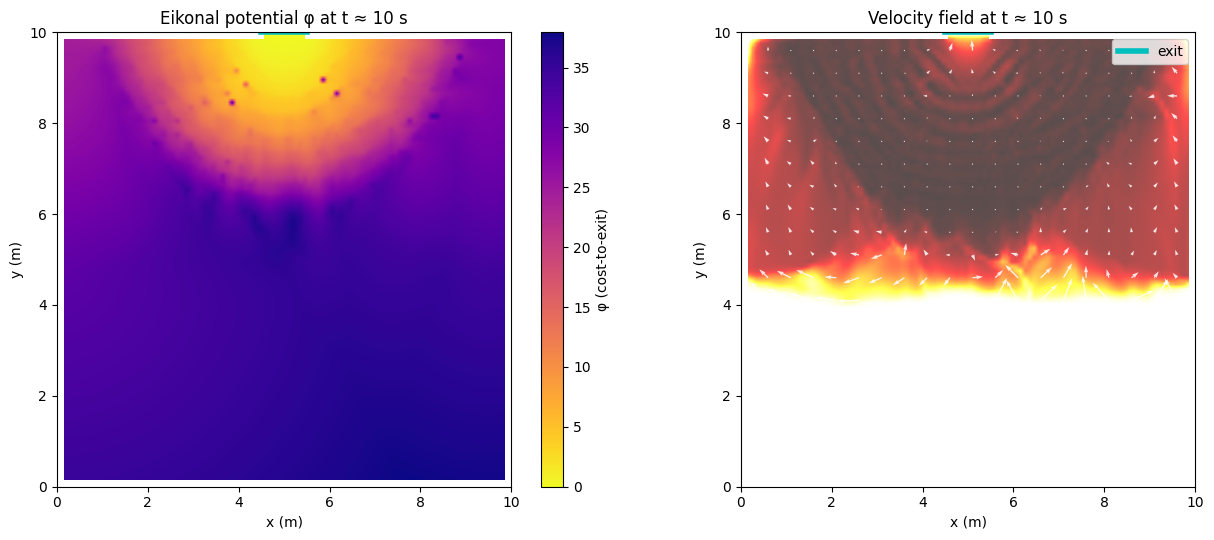

In [24]:
# ── Potential field φ at an intermediate time ─────────────────────────────────
# Recompute phi from the snapshot at t≈10 s (or the earliest available)
snap_t = min(snapshot_frames.keys(), key=lambda x: abs(x-10))
snap   = snapshot_frames[snap_t]

U_snap    = speed_fn(snap)
G_snap    = discomfort_fn(snap)
cost_snap = G_snap / np.maximum(U_snap, 1e-10)
cost_snap[boundary]  = 1.0e6
cost_snap[exit_zone] = 0.0
phi_snap = solve_eikonal_fast_sweeping(cost_snap, exit_zone, boundary, dx, dy)

# Velocity field for quiver
vx_snap, vy_snap = compute_velocity(phi_snap, snap, dx, dy, boundary, exit_zone)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# φ field
phi_vis = np.ma.masked_where(boundary, phi_snap)
im1 = ax1.imshow(phi_vis, origin='lower', cmap='plasma_r',
                 extent=[0, ROOM_W, 0, ROOM_H], interpolation='bilinear')
plt.colorbar(im1, ax=ax1, label='φ (cost-to-exit)')
ax1.set_title(f'Eikonal potential φ at t ≈ {snap_t:.0f} s', fontsize=12)
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
ax1.plot([col0*dx, col1*dx], [ROOM_H, ROOM_H], 'c-', lw=4)

# Velocity quiver (subsample for clarity)
step_q = 5
I = np.arange(1, NY-1, step_q)
J = np.arange(1, NX-1, step_q)
Jg, Ig = np.meshgrid(J*dx, I*dy)
ax2.imshow(np.ma.masked_where(boundary, snap), origin='lower', cmap='hot_r',
           extent=[0, ROOM_W, 0, ROOM_H], vmin=0, vmax=rho_max,
           interpolation='bilinear', alpha=0.7)
ax2.quiver(Jg, Ig, vx_snap[np.ix_(I, J)], vy_snap[np.ix_(I, J)],
           color='white', scale=25, width=0.003, alpha=0.85)
ax2.set_title(f'Velocity field at t ≈ {snap_t:.0f} s', fontsize=12)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
ax2.plot([col0*dx, col1*dx], [ROOM_H, ROOM_H], 'c-', lw=4, label='exit')
ax2.legend()

plt.tight_layout()
plt.savefig('hughes_phi_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

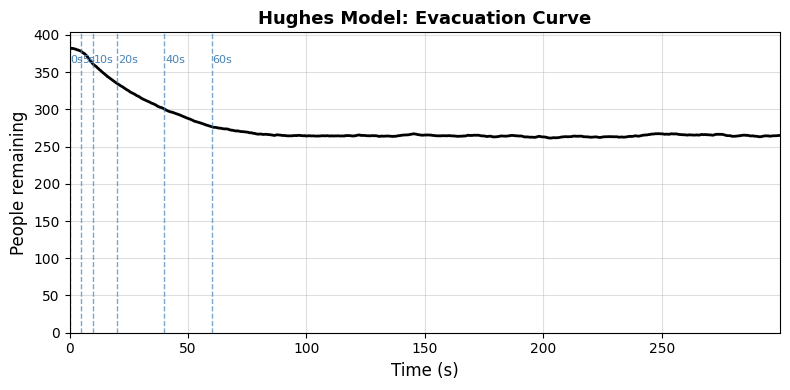

In [ ]:
# ── Evacuation curve ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evac_curve_t, evac_curve_pop, 'k-', lw=2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('People remaining', fontsize=12)
ax.set_title('Hughes Model: Evacuation Curve', fontsize=13, fontweight='bold')
ax.set_xlim(0, evac_curve_t[-1])
ax.set_ylim(0, evac_curve_pop[0] * 1.05)
ax.grid(True, alpha=0.4)

# Mark the snapshot times
for pt in PLOT_TIMES[:6]:
    if pt <= evac_curve_t[-1]:
        ax.axvline(pt, color='steelblue', lw=1, ls='--', alpha=0.7)
        ax.text(pt + 0.3, evac_curve_pop[0]*0.97, f'{pt}s',
                color='steelblue', fontsize=8, va='top')

plt.tight_layout()
plt.savefig('hughes_evac_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Half-life
half = evac_curve_pop[0] / 2
idx  = next((i for i,p in enumerate(evac_curve_pop) if p <= half), None)
if idx:
    print(f"Half-empty at t ≈ {evac_curve_t[idx]:.1f} s")

In [12]:
# ── Animation ─────────────────────────────────────────────────────────────────
fig_a, ax_a = plt.subplots(figsize=(6, 6))

init_vis  = np.ma.masked_where(boundary, anim_frames[0][1])
im_a = ax_a.imshow(init_vis, origin='lower', cmap='hot_r',
                   extent=[0, ROOM_W, 0, ROOM_H],
                   vmin=0, vmax=rho_max, interpolation='bilinear')
plt.colorbar(im_a, ax=ax_a, label='ρ (people/m²)')
ax_a.plot([col0*dx, col1*dx], [ROOM_H, ROOM_H], 'c-', lw=4, label='exit')
ax_a.legend(loc='lower right', fontsize=9)
ax_a.set_xlabel('x (m)'); ax_a.set_ylabel('y (m)')
ttl = ax_a.set_title('', fontsize=11)

def _anim_update(frame):
    t_f, rho_f = anim_frames[frame]
    im_a.set_array(np.ma.masked_where(boundary, rho_f))
    pop = np.sum(rho_f) * dx * dy
    ttl.set_text(f'Hughes Model  |  t = {t_f:.1f} s  |  {pop:.0f} people')
    return [im_a, ttl]

anim_h = FuncAnimation(fig_a, _anim_update, frames=len(anim_frames),
                        interval=80, blit=True, repeat=True)
plt.close(fig_a)
print("Rendering animation (HTML)...")
HTML(anim_h.to_jshtml())

Rendering animation (HTML)...
